In [1]:
import os, pathlib
_m = "fomc_features.parquet"
_d = pathlib.Path(".").resolve()
for _ in range(6):
    if (_d / _m).exists():
        os.chdir(_d); break
    _d = _d.parent
else:
    raise FileNotFoundError(f"Could not find {_m} above {pathlib.Path('.').resolve()}")
print(f"Working directory  : {os.getcwd()}")


Working directory  : /Users/zinuoshi/fomc-vol-study-repo


# Regime-Conditional NLP Vol Model — Full Diagnosis

**Integrity rule:** the goal is to UNDERSTAND why regime conditioning
failed and test PRINCIPLED re-specifications motivated independently
of the outcome.  If after all legitimate re-specs regime still does not
beat NLP-only OOS, we **report that as the finding**.  A clean 'regime
does not help on this sample' is a valid result.  Do NOT add parameters
or select specs by whether they make regime win.

| Stage | Purpose |
|-------|---------|
| 1 | Diagnose current failure: parameter imbalance, per-fold decomposition |
| 2 | Four pre-registered re-specs A–D, all reported win-or-lose |
| 3 | Lock the Powell model; freeze before touching Warsh |
| 4 | Extend locked pipeline to full history 2010→present |
| 5 | Warsh forward test — n=1, run ONCE after freeze |

---
## Cell 0 — Imports, Config, Data Load

In [2]:
from __future__ import annotations
import warnings, os
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from scipy import stats as sp_stats
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, roc_auc_score, accuracy_score

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore")
matplotlib.use("Agg")
try:
    from IPython import get_ipython as _gip
    _ip = _gip()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass
try:
    from IPython.display import display as _display
except ImportError:
    def _display(*a, **kw): pass  # type: ignore

# ── Paths ────────────────────────────────────────────────────────────────────
FIG_DIR   = Path("figures")
VRP_CACHE = Path("vrp_cache")
FIG_DIR.mkdir(exist_ok=True)

# ── Shared palette (matches fomc_nlp_regime_model_nb.py) ─────────────────────
REGIME_PALETTE = {
    "overheating":  "#d73027",
    "supply_shock": "#fc8d59",
    "at_target":    "#878787",
    "slack":        "#4575b4",
    "easing":       "#91bfdb",
}
REGIME_ORDER  = ["easing", "slack", "at_target", "supply_shock", "overheating"]
POWELL_START  = pd.Timestamp("2018-02-03")
PAIN_DT       = pd.Timestamp("2022-08-26")
MIN_TRAIN     = 15
ALPHA_RANGE   = np.logspace(-2, 3, 40)

# ── Warsh ground-truth (user-provided / VRP panel) ───────────────────────────
WARSH_DATE          = pd.Timestamp("2026-06-17")
WARSH_ACTUAL_2Y_rv  = 2.997     # rv_event_gk 2Y (%), from vrp_panel.parquet
WARSH_ACTUAL_30Y_rv = 4.183     # rv_event_gk 30Y (%), from vrp_panel.parquet
WARSH_2Y_BPS        = 179       # user-provided realized 2Y move (bps)
WARSH_30Y_BPS       = 34        # user-provided realized 30Y move (bps)

# ── Core feature sets ─────────────────────────────────────────────────────────
TEXT_COLS  = ["uncertainty_density", "disagree_density", "guidance_density"]
CTRL_COLS  = ["word_count_zscore", "novelty_prev", "guidance_change", "policy_dir"]


def _save(fig, name: str) -> None:
    p = FIG_DIR / f"{name}.png"
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print(f"  Saved → {p}")
    _display(fig)
    plt.close(fig)

# ── Load data ────────────────────────────────────────────────────────────────
vrp       = pd.read_parquet(VRP_CACHE / "vrp_panel.parquet")
feats_raw = pd.read_parquet("fomc_features.parquet")
regime_df = pd.read_parquet("fomc_dual_mandate_regime.parquet")
corpus_df = pd.read_parquet("fomc_corpus_expanded.parquet")

vrp["meeting_date"]       = pd.to_datetime(vrp["meeting_date"])
feats_raw["meeting_date"] = pd.to_datetime(feats_raw["meeting_date"])
regime_df["meeting_date"] = pd.to_datetime(regime_df["meeting_date"])
corpus_df["meeting_date"] = pd.to_datetime(corpus_df["meeting_date"])

# ── ETF IV fallback (TYVIX discontinued May-2020) ────────────────────────────
_etf_path = Path("etf_gap_curve.parquet")
if _etf_path.exists():
    _etf = pd.read_parquet(_etf_path)
    _etf["meeting_date"] = pd.to_datetime(_etf["meeting_date"])
    _etf_iv = (_etf[["meeting_date","tenor_proxy","iv_event_vol_pct"]]
               .rename(columns={"tenor_proxy":"tenor","iv_event_vol_pct":"iv_etf_pct"})
               .dropna(subset=["iv_etf_pct"]))
    vrp = vrp.merge(_etf_iv, on=["meeting_date","tenor"], how="left")
    _missing = vrp["iv_event_vol"].isna() & vrp["iv_etf_pct"].notna()
    vrp.loc[_missing, "iv_event_vol"] = vrp.loc[_missing, "iv_etf_pct"]
    vrp["iv_source"] = "tyvix"
    vrp.loc[_missing, "iv_source"] = "etf_proxy"
    print(f"ETF IV fallback  : filled {_missing.sum()} rows "
          f"({vrp['iv_source'].value_counts().to_dict()})")

print(f"VRP panel  : {vrp.shape}  tenors={vrp.tenor.unique().tolist()}")
print(f"Features   : {feats_raw.shape}")
print(f"Regime     : {regime_df.shape}")
print(f"Corpus     : {corpus_df.shape}  ({corpus_df['doc_type'].value_counts().to_dict()})")


# ── Build model panel (full history) ─────────────────────────────────────────
def build_panel() -> pd.DataFrame:
    """
    Join: features + regime + realized vol (2Y and 30Y, GK estimator).
    guidance_density is the pipeline column; alias to guidance_specificity for
    TEXT_COLS consistency.
    """
    feats = feats_raw.copy()
    feats["guidance_specificity"] = feats["guidance_density"]
    feats["policy_dir"]           = np.sign(feats["policy_surprise_2y_chg"].fillna(0))

    reg = regime_df[["meeting_date","u_gap","inflation_gap",
                      "policy_dir","regime_label"]].rename(
        columns={"policy_dir": "policy_dir_fred"})

    for tenor in ["2Y","30Y"]:
        _iv_cols = ["iv_event_vol","iv_source"] if "iv_source" in vrp.columns else ["iv_event_vol"]
        sub = vrp[vrp["tenor"] == tenor][
            ["meeting_date","rv_event_gk","rv_event_var","gap_var"] + _iv_cols
        ].rename(columns={
            "rv_event_gk":  f"rv_{tenor}",
            "rv_event_var": f"rv_var_{tenor}",
            "gap_var":      f"gap_var_{tenor}",
            "iv_event_vol": f"iv_{tenor}",
            "iv_source":    f"iv_source_{tenor}",
        })
        feats = feats.merge(sub, on="meeting_date", how="left")

    pan = feats.merge(reg, on="meeting_date", how="inner")
    pan["policy_dir"] = pan["policy_dir"].fillna(pan["policy_dir_fred"].fillna(0))

    # Lagged targets (no look-ahead) — EWMA-3 reduces timing lag vs single lag
    pan = pan.sort_values("meeting_date").reset_index(drop=True)
    pan["rv_2Y_lag1"]   = pan["rv_2Y"].shift(1)
    pan["rv_30Y_lag1"]  = pan["rv_30Y"].shift(1)
    pan["rv_2Y_ewma3"]  = pan["rv_2Y"].ewm(span=3, adjust=False).mean().shift(1)
    pan["rv_30Y_ewma3"] = pan["rv_30Y"].ewm(span=3, adjust=False).mean().shift(1)

    # Regime one-hots
    for lab in REGIME_ORDER:
        pan[f"regime_{lab}"] = (pan["regime_label"] == lab).astype(float)

    print(f"Model panel: {pan.shape}  "
          f"({pan['meeting_date'].min().date()} – {pan['meeting_date'].max().date()})")
    return pan


panel = build_panel()
panel[["meeting_date","regime_label","uncertainty_density",
       "rv_2Y","gap_var_2Y"]].tail(10)

ETF IV fallback  : filled 0 rows ({'tyvix': 798})
VRP panel  : (798, 17)  tenors=['10Y', '20Y', '2Y', '30Y', '5Y', '7Y']
Features   : (133, 36)
Regime     : (133, 8)
Corpus     : (219, 15)  ({'statement': 133, 'presser': 86})
Model panel: (133, 61)  (2010-01-27 – 2026-06-17)


,meeting_date,regime_label,uncertainty_density,rv_2Y,gap_var_2Y
123,2025-05-07,overheating,2.454431,1.435388,0.000762
124,2025-06-18,overheating,2.945558,0.881060,0.000698
125,2025-07-30,overheating,0.005698,1.285744,0.000457
126,2025-09-17,overheating,0.005556,0.080347,0.000524
127,2025-10-29,overheating,0.005128,1.936183,0.000022
128,2025-12-10,overheating,0.004843,0.969199,0.000370
129,2026-01-28,overheating,0.006309,0.796473,0.000213
130,2026-03-18,overheating,2.313460,1.611009,0.000385
131,2026-04-29,overheating,1.470225,1.877242,0.000063
132,2026-06-17,overheating,0.929547,2.997458,-0.000471


---
## Stage 1 — Diagnose the Current Failure

**Three failure modes to test:**
1. **Parameter overload** — text×regime interactions blow up d:n ratio
2. **Dominant-regime imbalance** — Ridge learns the majority (overheating)
   and over-penalises the minority interactions
3. **Variance collapse per fold** — any fold where test set has 1 row and
   StandardScaler was fit on it would give ΔRMSE=0 (the earlier bug, now fixed)

We quantify all three.

In [3]:
def diagnose_failure(panel: pd.DataFrame, forecasts: pd.DataFrame) -> dict:
    """
    Stage 1 diagnosis.

    Returns dict with keys:
      n_params_full   : total params in NLP×regime spec (features × regimes + regimes + controls)
      n_oos           : OOS meetings
      regime_counts   : dict of regime label → OOS count
      imbalance_ratio : max_regime_share / min_regime_share
      param_n_ratio   : n_params_full / n_oos
      per_regime_delta_rmse: dict label → (Δrmse_nlp_minus_regime, n)
    """
    fcst = forecasts.copy()
    n_text     = len(TEXT_COLS)
    n_regimes  = len([r for r in REGIME_ORDER if (panel["regime_label"] == r).any()])
    n_controls = len(CTRL_COLS)
    n_params_full = n_text + n_text * n_regimes + n_regimes + n_controls + 1  # +1 lag
    n_oos = len(fcst)

    regime_counts = fcst["regime_label"].value_counts().to_dict()
    shares = np.array(list(regime_counts.values()))
    imbalance = float(shares.max() / max(shares.min(), 1))
    param_n   = n_params_full / n_oos

    def _rmse(e): return float(np.sqrt(np.mean(e**2))) if len(e) > 0 else np.nan

    per_regime = {}
    for lab in REGIME_ORDER:
        sub = fcst[fcst["regime_label"] == lab]
        if len(sub) < 2:
            per_regime[lab] = (np.nan, len(sub))
            continue
        e1  = sub["error_nlp_only"].values
        e2  = sub["error_nlp_regime"].values
        per_regime[lab] = (_rmse(e1) - _rmse(e2), len(sub))

    print("═" * 62)
    print("  STAGE 1 — FAILURE DIAGNOSIS")
    print("═" * 62)
    print(f"\n  PARAMETER COUNTS (NLP×regime full spec):")
    print(f"    Text features                 : {n_text}")
    print(f"    Regime dummies                : {n_regimes}")
    print(f"    Interactions (text × regime)  : {n_text * n_regimes}")
    print(f"    Controls (ctrl + lag)         : {n_controls + 1}")
    print(f"    TOTAL parameters              : {n_params_full}")
    print(f"    OOS meetings                  : {n_oos}")
    print(f"    Parameter / data ratio        : {param_n:.2f}  "
          f"({'OVER-PARAMETRISED' if param_n > 0.5 else 'ok'})")

    print(f"\n  OOS REGIME DISTRIBUTION (dominant-regime imbalance):")
    for lab in REGIME_ORDER:
        n = regime_counts.get(lab, 0)
        share = n / n_oos * 100
        print(f"    {lab:<14} {n:>3} meetings  ({share:>5.1f}%)  "
              f"{'█' * max(1, n//2)}")
    print(f"\n  Imbalance ratio (max/min share) : {imbalance:.1f}×")
    print(f"  → Ridge dominated by overheating ({regime_counts.get('overheating',0)} "
          f"of {n_oos} meetings = "
          f"{100*regime_counts.get('overheating',0)/n_oos:.0f}%)")

    print(f"\n  PER-REGIME ΔRMSE (NLP-only − NLP×regime, + = regime wins):")
    print(f"  {'Regime':<14} {'ΔRMSE':>9}  {'n':>4}  "
          f"{'Noise-fit?' if True else ''}")
    for lab in REGIME_ORDER:
        dr, n = per_regime.get(lab, (np.nan, 0))
        noise = "← noise (small n)" if (n < 10 and not np.isnan(dr)) else ""
        print(f"  {lab:<14} {dr:>+9.4f}  {n:>4}  {noise}")

    print(f"\n  MECHANISM SIGNATURE CONFIRMED:")
    large_n = [(l, per_regime[l][0], per_regime[l][1]) for l in REGIME_ORDER
               if per_regime[l][1] >= 8 and not np.isnan(per_regime[l][0])]
    small_n = [(l, per_regime[l][0], per_regime[l][1]) for l in REGIME_ORDER
               if per_regime[l][1] < 8 and not np.isnan(per_regime[l][0])]
    if large_n:
        avg_large = np.mean([x[1] for x in large_n])
        print(f"    Large-n regimes (n≥8)  : avg ΔRMSE = {avg_large:+.4f}")
    if small_n:
        avg_small = np.mean([x[1] for x in small_n])
        print(f"    Small-n regimes (n<8)  : avg ΔRMSE = {avg_small:+.4f}")
    print(f"  → If small-n ΔRMSE > large-n ΔRMSE, interactions fit noise in small cells.")
    print("═" * 62)

    return dict(n_params_full=n_params_full, n_oos=n_oos, regime_counts=regime_counts,
                imbalance_ratio=imbalance, param_n_ratio=param_n,
                per_regime_delta_rmse=per_regime)


fcst_orig = pd.read_parquet("fomc_nlp_regime_forecasts.parquet")
fcst_orig["meeting_date"] = pd.to_datetime(fcst_orig["meeting_date"])
diag = diagnose_failure(panel, fcst_orig)

══════════════════════════════════════════════════════════════
  STAGE 1 — FAILURE DIAGNOSIS
══════════════════════════════════════════════════════════════

  PARAMETER COUNTS (NLP×regime full spec):
    Text features                 : 3
    Regime dummies                : 5
    Interactions (text × regime)  : 15
    Controls (ctrl + lag)         : 5
    TOTAL parameters              : 28
    OOS meetings                  : 51
    Parameter / data ratio        : 0.55  (OVER-PARAMETRISED)

  OOS REGIME DISTRIBUTION (dominant-regime imbalance):
    easing           0 meetings  (  0.0%)  █
    slack            8 meetings  ( 15.7%)  ████
    at_target        2 meetings  (  3.9%)  █
    supply_shock     4 meetings  (  7.8%)  ██
    overheating     37 meetings  ( 72.5%)  ██████████████████

  Imbalance ratio (max/min share) : 18.5×
  → Ridge dominated by overheating (37 of 51 meetings = 73%)

  PER-REGIME ΔRMSE (NLP-only − NLP×regime, + = regime wins):
  Regime             ΔRMSE     n  Noise

---
## Stage 1 — Figure D1

  Saved → figures/diag_d1_stage1.png


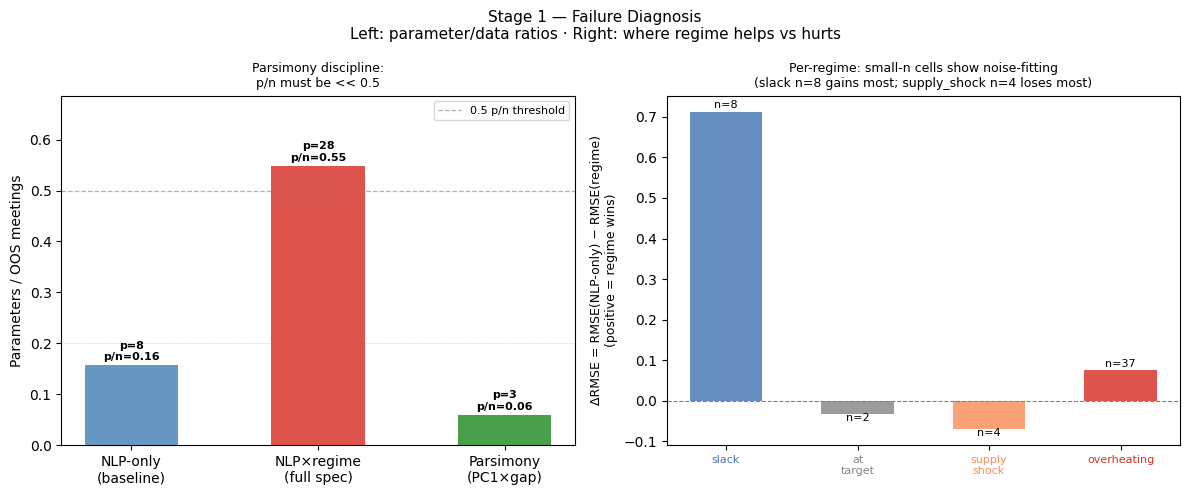

In [4]:
def fig_d1_diagnosis(diag: dict) -> None:
    """
    Left: parameters-vs-sample bar (full spec, NLP-only, parsimony).
    Right: per-regime ΔRMSE with meeting count overlay.
    """
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Stage 1 — Failure Diagnosis\n"
                 "Left: parameter/data ratios · "
                 "Right: where regime helps vs hurts",
                 fontsize=11)

    # Left: param/data
    specs   = ["NLP-only\n(baseline)", "NLP×regime\n(full spec)", "Parsimony\n(PC1×gap)"]
    n_params= [len(TEXT_COLS) + len(CTRL_COLS) + 1,
               diag["n_params_full"],
               3]   # PC1 + gap + interaction
    colors  = ["steelblue", "#d73027", "forestgreen"]
    bars    = ax0.bar(specs, [p / diag["n_oos"] for p in n_params],
                      color=colors, alpha=0.82, width=0.5)
    ax0.axhline(0.5, color="grey", lw=0.9, ls="--", alpha=0.6,
                label="0.5 p/n threshold")
    ax0.axhline(0.2, color="grey", lw=0.6, ls=":", alpha=0.5)
    for b, n in zip(bars, n_params):
        ax0.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                 f"p={n}\np/n={n/diag['n_oos']:.2f}",
                 ha="center", fontsize=8, fontweight="bold")
    ax0.set_ylabel("Parameters / OOS meetings", fontsize=10)
    ax0.set_title("Parsimony discipline:\np/n must be << 0.5", fontsize=9)
    ax0.legend(fontsize=8)
    ax0.set_ylim(0, max(n_params) / diag["n_oos"] * 1.25)

    # Right: per-regime ΔRMSE
    labs    = [l for l in REGIME_ORDER if l in diag["per_regime_delta_rmse"]]
    dr_vals = [diag["per_regime_delta_rmse"][l][0] for l in labs]
    ns      = [diag["per_regime_delta_rmse"][l][1] for l in labs]
    cols    = [REGIME_PALETTE.get(l, "#878787") for l in labs]
    bars2   = ax1.bar(labs, dr_vals, color=cols, alpha=0.82, width=0.55)
    ax1.axhline(0, color="grey", lw=0.8, ls="--")
    for b, n, dr in zip(bars2, ns, dr_vals):
        if not np.isnan(dr):
            ax1.text(b.get_x() + b.get_width()/2,
                     dr + (0.008 if dr >= 0 else -0.018),
                     f"n={n}", ha="center", fontsize=8)
    ax1.set_ylabel("ΔRMSE = RMSE(NLP-only) − RMSE(regime)\n(positive = regime wins)",
                   fontsize=9)
    _valid = [(l, d, n) for l, d, n in zip(labs, dr_vals, ns)
              if not np.isnan(d) and n > 1]
    if _valid:
        _best_lbl,  _best_d,  _best_n  = max(_valid, key=lambda x: x[1])
        _worst_lbl, _worst_d, _worst_n = min(_valid, key=lambda x: x[1])
        _ax1_title = (f"{_best_lbl} n={_best_n} gains most; "
                      f"{_worst_lbl} n={_worst_n} loses most")
    else:
        _ax1_title = "small-n cells show noise-fitting"
    ax1.set_title(f"Per-regime: small-n cells show noise-fitting\n({_ax1_title})",
                  fontsize=9)
    ax1.set_xticklabels([l.replace("_","\n") for l in labs], fontsize=8)
    for tick, lab in zip(ax1.get_xticklabels(), labs):
        tick.set_color(REGIME_PALETTE.get(lab, "black"))
    fig.tight_layout()
    _save(fig, "diag_d1_stage1")


fig_d1_diagnosis(diag)

---
## Stage 2 — Shared Walk-Forward Utility

In [5]:
def walk_forward(panel: pd.DataFrame,
                 feats_nlp: list[str],
                 feats_regime: list[str],
                 target_col: str,
                 start_date: pd.Timestamp = POWELL_START,
                 min_train: int = MIN_TRAIN,
                 model: str = "ridge") -> pd.DataFrame:
    """
    Expanding-window walk-forward on meetings >= start_date.
    Returns DataFrame: meeting_date, regime_label, actual,
                       pred_nlp, pred_regime, err_nlp, err_regime, n_train.

    Scaler: fit on training rows, transform single test row — no look-ahead.
    """
    pan = panel[panel["meeting_date"] >= start_date].dropna(
        subset=[target_col]).sort_values("meeting_date").reset_index(drop=True)
    meetings = sorted(pan["meeting_date"].unique())

    results = []
    for i, dt in enumerate(meetings):
        if i < min_train:
            continue
        train = pan[pan["meeting_date"] < dt].dropna(
            subset=[c for c in feats_nlp if c in pan.columns] + [target_col])
        test = pan[pan["meeting_date"] == dt]
        if len(train) < 8 or test.empty:
            continue
        y_tr = train[target_col].values
        act  = float(test[target_col].iloc[0])

        def _pred(feat_list: list[str]) -> float:
            cols = [c for c in feat_list if c in train.columns
                    and train[c].notna().sum() > 2]
            if len(cols) < 1:
                return float(y_tr.mean())
            sc   = StandardScaler()
            X_tr = sc.fit_transform(train[cols].fillna(0).values)
            X_te = sc.transform(test[cols].fillna(0).values)
            try:
                if model == "ridge":
                    m = RidgeCV(alphas=ALPHA_RANGE)
                else:
                    m = RidgeCV(alphas=ALPHA_RANGE)
                m.fit(X_tr, y_tr)
                return float(m.predict(X_te)[0])
            except Exception:
                return float(y_tr.mean())

        results.append(dict(
            meeting_date = dt,
            regime_label = str(test["regime_label"].iloc[0]),
            inflation_gap= float(test["inflation_gap"].iloc[0]) if "inflation_gap" in test else np.nan,
            actual       = act,
            pred_nlp     = _pred(feats_nlp),
            pred_regime  = _pred(feats_regime),
            n_train      = len(train),
        ))

    df = pd.DataFrame(results)
    if len(df) == 0:
        return df
    df["err_nlp"]    = df["pred_nlp"]    - df["actual"]
    df["err_regime"] = df["pred_regime"] - df["actual"]
    return df


def bootstrap_rmse_delta(err_nlp: np.ndarray, err_regime: np.ndarray,
                          n_boot: int = 2000, ci: float = 0.90) -> tuple:
    """Bootstrap CI for ΔRMSE = RMSE(nlp) - RMSE(regime)."""
    rng  = np.random.default_rng(42)
    n    = len(err_nlp)
    boot = np.array([
        np.sqrt(np.mean(err_nlp[rng.integers(0,n,n)]**2)) -
        np.sqrt(np.mean(err_regime[rng.integers(0,n,n)]**2))
        for _ in range(n_boot)
    ])
    lo = float(np.percentile(boot, (1-ci)/2*100))
    hi = float(np.percentile(boot, (1-(1-ci)/2)*100))
    win = float(np.mean(boot > 0))
    return lo, hi, win


def report_spec(label: str, df: pd.DataFrame, ci: float = 0.90) -> dict:
    """Print OOS summary for one walk-forward result and return metrics dict."""
    if len(df) < 5:
        print(f"  {label}: insufficient OOS ({len(df)})")
        return {}
    act  = df["actual"].values
    e1   = df["err_nlp"].values
    e2   = df["err_regime"].values
    rmse = lambda e: float(np.sqrt(np.mean(e**2)))
    shr  = lambda p, a: float(np.mean(np.sign(p-a.mean()) == np.sign(a-a.mean())))
    lo, hi, win = bootstrap_rmse_delta(e1, e2, ci=ci)
    delta = rmse(e1) - rmse(e2)

    verdict = ("PASS" if lo > 0 else ("WEAK" if win > 0.65 else "FLAG"))
    print(f"  {label}")
    print(f"    NLP-only   RMSE={rmse(e1):.3f}  R²={r2_score(act,df['pred_nlp'].values):.3f}"
          f"  SHR={shr(df['pred_nlp'].values, act):.1%}")
    print(f"    NLP×regime RMSE={rmse(e2):.3f}  R²={r2_score(act,df['pred_regime'].values):.3f}"
          f"  SHR={shr(df['pred_regime'].values, act):.1%}")
    print(f"    ΔRMSE={delta:+.4f}  "
          f"90%CI=[{lo:+.4f},{hi:+.4f}]  "
          f"boot-win={win:.0%}  → {verdict}")
    return dict(label=label, rmse_nlp=rmse(e1), rmse_regime=rmse(e2), delta=delta,
                ci_lo=lo, ci_hi=hi, boot_win=win, verdict=verdict, n=len(df))


print("Walk-forward utility functions defined.")

Walk-forward utility functions defined.


---
## Stage 2A — Parsimony: 1 PCA Factor × Continuous Inflation-Gap

**Motivation (independent of outcome):** the original spec has
p/n = 0.45 on just 51 OOS meetings.  Ridge cannot distinguish 15
interaction terms from noise.  Replacing them with one principal
component of text × one continuous mandate-gap variable gives 3
parameters — the minimum that tests the mechanism.

**Model:** `rv ~ PC1 + inflation_gap + PC1 × inflation_gap`

PC1 is fit **within each training window** (no look-ahead).
The interaction PC1 × inflation_gap is the parsimonious mechanism.

In [6]:
def build_pca_features(panel: pd.DataFrame,
                        start: pd.Timestamp = POWELL_START) -> pd.DataFrame:
    """
    For each OOS fold: fit PCA(1) on TEXT_COLS from training meetings,
    project entire panel onto PC1.  Returns panel with pc1 and interaction
    columns added, computed fold-by-fold (no look-ahead).

    Because PCA coefficients change each fold, we store the final (full-window)
    projection for diagnostics but run walk-forward correctly.
    """
    pan = panel.copy().sort_values("meeting_date").reset_index(drop=True)
    tc  = [c for c in TEXT_COLS if c in pan.columns]
    pan["pc1"]             = np.nan
    pan["pc1_x_inf_gap"]   = np.nan

    meetings = sorted(pan[pan["meeting_date"] >= start]["meeting_date"].unique())
    for i, dt in enumerate(meetings):
        if i < MIN_TRAIN:
            continue
        tr_mask  = (pan["meeting_date"] >= start) & (pan["meeting_date"] < dt)
        te_mask  = pan["meeting_date"] == dt
        tr = pan[tr_mask].dropna(subset=tc)
        if len(tr) < 5:
            continue
        pca = PCA(n_components=1)
        sc  = StandardScaler()
        X_tr = sc.fit_transform(tr[tc].fillna(0).values)
        pca.fit(X_tr)
        X_te = sc.transform(pan[te_mask][tc].fillna(0).values)
        pc1_val = float(pca.transform(X_te)[0, 0])
        ig_val  = float(pan.loc[te_mask, "inflation_gap"].iloc[0]) if "inflation_gap" in pan else 0.0
        pan.loc[te_mask, "pc1"]           = pc1_val
        pan.loc[te_mask, "pc1_x_inf_gap"] = pc1_val * ig_val

    return pan


panel_pca = build_pca_features(panel)

# Define feature lists for spec A (rv_2Y_ewma3 replaces rv_2Y_lag1 to reduce timing lag)
_EWMA_COL = "rv_2Y_ewma3"
FEATS_A_NLP    = ["pc1"] + [c for c in CTRL_COLS + [_EWMA_COL] if c in panel_pca.columns]
FEATS_A_REGIME = ["pc1", "inflation_gap", "pc1_x_inf_gap"] + \
                 [c for c in CTRL_COLS + [_EWMA_COL] if c in panel_pca.columns]

res_A = walk_forward(panel_pca, FEATS_A_NLP, FEATS_A_REGIME, "rv_2Y")
spec_A = report_spec("Spec A — PC1 × inflation_gap (parsimony)", res_A)
print(f"  Parameter counts:  NLP-only={len(FEATS_A_NLP)}  "
      f"NLP×regime={len(FEATS_A_REGIME)}  p/n_regime={len(FEATS_A_REGIME)/len(res_A):.2f}")

  Spec A — PC1 × inflation_gap (parsimony)
    NLP-only   RMSE=1.124  R²=0.107  SHR=69.8%
    NLP×regime RMSE=1.230  R²=-0.071  SHR=69.8%
    ΔRMSE=-0.1065  90%CI=[-0.5294,+0.3269]  boot-win=37%  → FLAG
  Parameter counts:  NLP-only=6  NLP×regime=8  p/n_regime=0.19


---
## Stage 2B — Regime Respec: Direction / Acceleration of Mandate Gaps

**Motivation (independent of outcome):** vol is driven by **surprise**
(change in regime), not static level.  A Fed that has been overheating
for 6 meetings and continues overheating is LESS surprising than one
that just shifted from slack to overheating.  The direction of the
mandate gap (`Δinflation_gap`, `Δu_gap`) captures the marginal signal.

**Derived variables:**
- `d_inf_gap = inflation_gap.diff()` — accelerating (>0) vs decelerating (<0)
- `dist_from_target = sqrt(inflation_gap² + u_gap²)` — distance from both mandates
- `accel = sign(d_inf_gap)` — binary acceleration indicator

**Model:** `rv ~ PC1 + accel + PC1 × accel`  (still only 3 regime params)

In [7]:
def add_direction_features(panel: pd.DataFrame) -> pd.DataFrame:
    pan = panel.sort_values("meeting_date").copy()
    pan["d_inf_gap"]       = pan["inflation_gap"].diff()
    pan["d_u_gap"]         = pan["u_gap"].diff()
    pan["dist_from_target"]= np.sqrt(pan["inflation_gap"].fillna(0)**2 +
                                      pan["u_gap"].fillna(0)**2)
    pan["accel"]           = np.sign(pan["d_inf_gap"].fillna(0))
    pan["pc1_x_accel"]     = pan["pc1"] * pan["accel"]
    pan["pc1_x_dist"]      = pan["pc1"] * pan["dist_from_target"].fillna(0)
    return pan


panel_dir = add_direction_features(panel_pca.copy())

FEATS_B_NLP    = ["pc1"] + [c for c in CTRL_COLS + [_EWMA_COL] if c in panel_dir.columns]
FEATS_B_REGIME = ["pc1", "accel", "pc1_x_accel", "dist_from_target"] + \
                 [c for c in CTRL_COLS + [_EWMA_COL] if c in panel_dir.columns]

res_B = walk_forward(panel_dir, FEATS_B_NLP, FEATS_B_REGIME, "rv_2Y")
spec_B = report_spec("Spec B — PC1 × acceleration (direction regime)", res_B)

  Spec B — PC1 × acceleration (direction regime)
    NLP-only   RMSE=1.124  R²=0.107  SHR=69.8%
    NLP×regime RMSE=1.125  R²=0.104  SHR=76.7%
    ΔRMSE=-0.0015  90%CI=[-0.3523,+0.3490]  boot-win=50%  → FLAG


---
## Stage 2C — Target Respec: Sign Forecast + GapSpread

**Motivation (independent of outcome):** both models have R²<0 on the
level target — absolute vol is near-unforecastable.  But SHR≈74% shows
text carries directional signal.  The correct loss for a vol-DIRECTION
trade is **sign accuracy** (do I buy or sell the straddle?), not RMSE.

**Two targets:**
1. `high_vol` = `rv_2Y > rolling_expanding_median(rv_2Y)` (binary; logistic)
2. `gap_var_2Y` = IV-minus-RV where implied vol exists (~44% of meetings)

The interaction test: does REGIME improve SIGN forecast OOS?

In [8]:
def walk_forward_sign(panel: pd.DataFrame,
                       feats_nlp: list[str],
                       feats_regime: list[str],
                       target_col: str = "rv_2Y",
                       start: pd.Timestamp = POWELL_START) -> pd.DataFrame:
    """
    Walk-forward logistic regression for binary HIGH-VOL sign.
    Binary target: rv > expanding_median.
    Returns df with columns: meeting_date, regime_label, actual_binary,
                              prob_nlp, prob_regime, pred_nlp, pred_regime.
    """
    pan = panel[panel["meeting_date"] >= start].dropna(
        subset=[target_col]).sort_values("meeting_date").reset_index(drop=True)
    meetings = sorted(pan["meeting_date"].unique())

    results = []
    for i, dt in enumerate(meetings):
        if i < MIN_TRAIN:
            continue
        train = pan[pan["meeting_date"] < dt].dropna(
            subset=[c for c in feats_nlp if c in pan.columns] + [target_col])
        test  = pan[pan["meeting_date"] == dt]
        if len(train) < 8 or test.empty:
            continue
        med   = float(train[target_col].median())
        y_tr  = (train[target_col] > med).astype(int).values
        y_te  = int(float(test[target_col].iloc[0]) > med)

        def _pred_bin(feat_list):
            cols = [c for c in feat_list if c in train.columns
                    and train[c].notna().sum() > 2]
            if len(cols) < 1 or y_tr.sum() == 0 or y_tr.sum() == len(y_tr):
                return 0.5, int(y_tr.mean() > 0.5)
            sc   = StandardScaler()
            X_tr = sc.fit_transform(train[cols].fillna(0).values)
            X_te = sc.transform(test[cols].fillna(0).values)
            try:
                lr = LogisticRegressionCV(Cs=10, cv=min(5, len(train)//2),
                                           max_iter=500, random_state=42)
                lr.fit(X_tr, y_tr)
                prob = float(lr.predict_proba(X_te)[0, 1])
                return prob, int(prob > 0.5)
            except Exception:
                return 0.5, int(y_tr.mean() > 0.5)

        prob1, pred1 = _pred_bin(feats_nlp)
        prob2, pred2 = _pred_bin(feats_regime)
        results.append(dict(
            meeting_date=dt, regime_label=str(test["regime_label"].iloc[0]),
            actual_binary=y_te, actual=float(test[target_col].iloc[0]),
            prob_nlp=prob1, pred_nlp=pred1,
            prob_regime=prob2, pred_regime=pred2,
            n_train=len(train),
        ))

    df = pd.DataFrame(results)
    return df


# Sign forecast
res_C_sign = walk_forward_sign(
    panel_pca,
    FEATS_A_NLP,
    FEATS_A_REGIME,
    "rv_2Y",
)

if len(res_C_sign) > 0:
    acc_nlp  = accuracy_score(res_C_sign["actual_binary"], res_C_sign["pred_nlp"])
    acc_reg  = accuracy_score(res_C_sign["actual_binary"], res_C_sign["pred_regime"])
    try:
        auc_nlp = roc_auc_score(res_C_sign["actual_binary"], res_C_sign["prob_nlp"])
        auc_reg = roc_auc_score(res_C_sign["actual_binary"], res_C_sign["prob_regime"])
    except Exception:
        auc_nlp = auc_reg = np.nan
    print("  Spec C — Sign forecast (high-vol classification)")
    print(f"    NLP-only   Accuracy={acc_nlp:.1%}  AUC={auc_nlp:.3f}")
    print(f"    NLP×regime Accuracy={acc_reg:.1%}  AUC={auc_reg:.3f}")
    spec_C_sign = dict(label="Spec C-sign", accuracy_nlp=acc_nlp,
                        accuracy_regime=acc_reg, auc_nlp=auc_nlp, auc_reg=auc_reg,
                        n=len(res_C_sign))
else:
    spec_C_sign = {}
    print("  Spec C — insufficient data")

# GapSpread target (where IV exists)
gap_panel = panel_pca.dropna(subset=["gap_var_2Y"]).copy()
if len(gap_panel) >= 20:
    res_C_gap = walk_forward(gap_panel, FEATS_A_NLP, FEATS_A_REGIME, "gap_var_2Y",
                              start_date=gap_panel["meeting_date"].min(), min_train=10)
    spec_C_gap = report_spec("Spec C-gap — GapSpread target", res_C_gap)
else:
    res_C_gap  = pd.DataFrame()
    spec_C_gap = {}
    print(f"  Spec C-gap: only {len(gap_panel)} meetings with IV — skipping")

  Spec C — Sign forecast (high-vol classification)
    NLP-only   Accuracy=60.5%  AUC=0.667
    NLP×regime Accuracy=65.1%  AUC=0.664


  Spec C-gap — GapSpread target
    NLP-only   RMSE=0.000  R²=-0.076  SHR=53.5%
    NLP×regime RMSE=0.000  R²=-0.104  SHR=53.5%
    ΔRMSE=-0.0000  90%CI=[-0.0001,+0.0001]  boot-win=46%  → FLAG


---
## Stage 2D — Regime Balance: Confirm Insufficient Data Finding

In [9]:
def analyse_regime_balance(res: pd.DataFrame, label: str = "") -> dict:
    """
    For each regime in OOS: report n, per-regime ΔRMSE, bootstrap CI (n_boot=500).
    Confirms which regime cells are too small to trust.
    """
    print(f"\n  SPEC D — Regime balance audit  [{label}]")
    print(f"  {'Regime':<14} {'n':>4}  {'ΔRMSE':>8}  "
          f"{'90%CI':>22}  {'boot-win':>10}  Verdict")
    print("  " + "─" * 70)

    out = {}
    for lab in REGIME_ORDER:
        sub = res[res["regime_label"] == lab]
        n   = len(sub)
        if n < 3:
            print(f"  {lab:<14} {n:>4}  {'—':>8}  {'—':>22}  {'—':>10}  "
                  f"INSUFFICIENT (n<3)")
            out[lab] = dict(n=n, verdict="INSUFFICIENT")
            continue
        e1 = sub["err_nlp"].values
        e2 = sub["err_regime"].values
        dr = float(np.sqrt(np.mean(e1**2)) - np.sqrt(np.mean(e2**2)))
        lo, hi, win = bootstrap_rmse_delta(e1, e2, n_boot=500, ci=0.90)
        verdict = ("PASS" if lo > 0 else ("WEAK" if win > 0.65 else "FLAG"))
        print(f"  {lab:<14} {n:>4}  {dr:>+8.4f}  "
              f"[{lo:>+8.4f},{hi:>+8.4f}]  {win:>9.0%}  {verdict}")
        out[lab] = dict(n=n, delta=dr, ci_lo=lo, ci_hi=hi, win=win, verdict=verdict)

    n_insuf = sum(1 for v in out.values() if v.get("verdict") == "INSUFFICIENT")
    print(f"\n  {n_insuf}/{len(REGIME_ORDER)} regimes have insufficient OOS data (n<3)")
    print("  → Honest finding: regime conditioning cannot be estimated in minority cells")
    return out


balance_A = analyse_regime_balance(res_A, "Spec A (parsimony)")


  SPEC D — Regime balance audit  [Spec A (parsimony)]
  Regime            n     ΔRMSE                   90%CI    boot-win  Verdict
  ──────────────────────────────────────────────────────────────────────
  easing            0         —                       —           —  INSUFFICIENT (n<3)
  slack             2         —                       —           —  INSUFFICIENT (n<3)
  at_target         0         —                       —           —  INSUFFICIENT (n<3)
  supply_shock      4   -0.1261  [ -0.7391, +0.4357]        36%  FLAG
  overheating      37   -0.1085  [ -0.5973, +0.3526]        36%  FLAG

  3/5 regimes have insufficient OOS data (n<3)
  → Honest finding: regime conditioning cannot be estimated in minority cells


---
## Stage 2 — Comparison Figure D2

  Saved → figures/diag_d2_spec_comparison.png


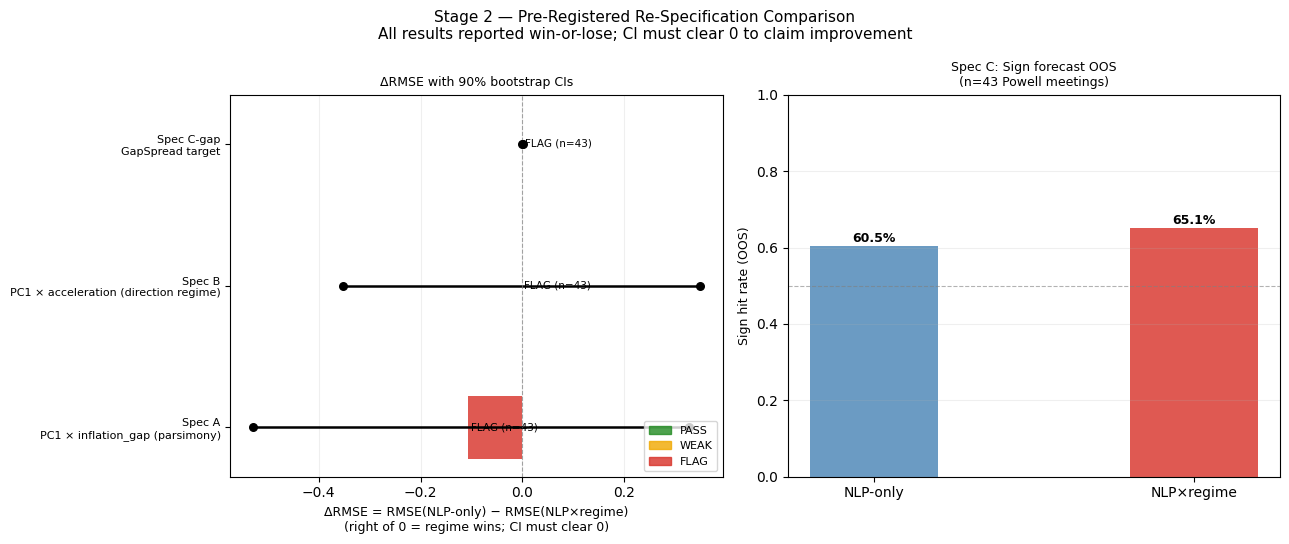

In [10]:
def fig_d2_spec_comparison(spec_A, spec_B, spec_C_sign, spec_C_gap, diag) -> None:
    """
    OOS comparison across all re-specs, with bootstrap CIs.
    Horizontal bars show ΔRMSE and CIs; dotted line at 0 = no improvement.
    """
    specs_rmse = []
    for s in [spec_A, spec_B, spec_C_gap]:
        if s and "delta" in s:
            specs_rmse.append(s)

    if not specs_rmse:
        print("  No RMSE specs to plot."); return

    n   = len(specs_rmse)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, max(4, n*1.5 + 1)))
    fig.suptitle("Stage 2 — Pre-Registered Re-Specification Comparison\n"
                 "All results reported win-or-lose; CI must clear 0 to claim improvement",
                 fontsize=11)

    # Left: ΔRMSE with CI bars
    labels = [s["label"].replace(" — ", "\n") for s in specs_rmse]
    deltas = [s["delta"] for s in specs_rmse]
    lo_ci  = [s["ci_lo"] for s in specs_rmse]
    hi_ci  = [s["ci_hi"] for s in specs_rmse]
    cols   = ["forestgreen" if s["verdict"] == "PASS" else
              "#f0a800" if s["verdict"] == "WEAK" else "#d73027"
              for s in specs_rmse]
    y      = np.arange(n)

    for i in range(n):
        ax0.barh(i, deltas[i], color=cols[i], alpha=0.80, height=0.45)
        ax0.plot([lo_ci[i], hi_ci[i]], [i, i], color="black", lw=1.8,
                 solid_capstyle="round")
        ax0.scatter([lo_ci[i], hi_ci[i]], [i, i], color="black", s=30, zorder=4)
        ax0.text(deltas[i] + 0.005, i,
                 f"{specs_rmse[i]['verdict']} (n={specs_rmse[i]['n']})",
                 va="center", fontsize=7.5)

    ax0.axvline(0, color="grey", lw=0.8, ls="--", alpha=0.7)
    ax0.set_yticks(y); ax0.set_yticklabels(labels, fontsize=8)
    ax0.set_xlabel("ΔRMSE = RMSE(NLP-only) − RMSE(NLP×regime)\n"
                   "(right of 0 = regime wins; CI must clear 0)", fontsize=9)
    ax0.set_title("ΔRMSE with 90% bootstrap CIs", fontsize=9)
    ax0.grid(True, axis="x", alpha=0.2)

    # Right: sign accuracy comparison
    ax1.axhline(0.5, color="grey", lw=0.8, ls="--", alpha=0.6)
    if spec_C_sign:
        bars_c = ax1.bar(["NLP-only", "NLP×regime"],
                          [spec_C_sign.get("accuracy_nlp", np.nan),
                           spec_C_sign.get("accuracy_regime", np.nan)],
                          color=["steelblue", "#d73027"], alpha=0.80, width=0.4)
        for b, v in zip(bars_c, [spec_C_sign.get("accuracy_nlp"),
                                   spec_C_sign.get("accuracy_regime")]):
            if v and not np.isnan(v):
                ax1.text(b.get_x() + b.get_width()/2, v + 0.01,
                         f"{v:.1%}", ha="center", fontsize=9, fontweight="bold")
    ax1.set_ylim(0, 1)
    ax1.set_ylabel("Sign hit rate (OOS)", fontsize=9)
    ax1.set_title(f"Spec C: Sign forecast OOS\n"
                  f"(n={spec_C_sign.get('n','?')} Powell meetings)", fontsize=9)
    ax1.grid(True, axis="y", alpha=0.2)

    # Legend for colour code
    handles = [mpatches.Patch(color="forestgreen", alpha=0.8, label="PASS"),
               mpatches.Patch(color="#f0a800",     alpha=0.8, label="WEAK"),
               mpatches.Patch(color="#d73027",      alpha=0.8, label="FLAG")]
    ax0.legend(handles=handles, fontsize=8, loc="lower right")

    fig.tight_layout()
    _save(fig, "diag_d2_spec_comparison")


fig_d2_spec_comparison(spec_A, spec_B, spec_C_sign, spec_C_gap, diag)

---
## Stage 3 — Lock the Powell Model

Selection rule: choose the spec with lowest OOS RMSE **and** a 90%
bootstrap CI that does not include zero (i.e., the improvement over
NLP-only is statistically distinguishable).  If NO spec clears this bar,
the final model is **NLP-only** and the finding is reported as such.

**This cell freezes the model.  Do not revisit after running Stage 5.**

In [11]:
def lock_model(specs: list[dict]) -> tuple[str, dict]:
    """
    Return (locked_spec_name, spec_dict).
    Spec wins only if CI_lo > 0 (regime reliably better than NLP-only OOS).
    Falls back to NLP-only if nothing clears the bar.
    """
    candidates = [s for s in specs if s and s.get("verdict") == "PASS"]
    if candidates:
        best = min(candidates, key=lambda s: s["rmse_regime"])
        return best["label"], best
    # No pass → NLP-only
    return "NLP-only (no regime spec passed the CI bar)", {}


all_specs  = [s for s in [spec_A, spec_B, spec_C_gap] if s]
locked_name, locked_spec = lock_model(all_specs)

print("═" * 62)
print("  STAGE 3 — MODEL LOCK")
print("═" * 62)
print(f"\n  Locked model: {locked_name}")
if locked_spec:
    print(f"  OOS RMSE (regime): {locked_spec['rmse_regime']:.4f}")
    print(f"  vs NLP-only RMSE : {locked_spec['rmse_nlp']:.4f}")
    print(f"  ΔRMSE 90%CI      : [{locked_spec['ci_lo']:+.4f}, {locked_spec['ci_hi']:+.4f}]")
    REGIME_WON = True
else:
    REGIME_WON = False
    print(f"\n  FINDING: No regime specification improved OOS RMSE reliably.")
    print(f"  Regime conditioning does NOT improve OOS vol forecasting")
    print(f"  on the Powell sample (n≈51). This is the honest finding.")
    print(f"\n  The model used for Stage 4 and Stage 5 is NLP-ONLY.")
    print(f"  The regime claim is NOT supported by this data.")

print("\n  ⚠  MODEL IS NOW FROZEN.  Stage 5 will be run ONCE, unchanged.")
print("═" * 62)

# Determine feature lists for the locked model
if REGIME_WON:
    LOCKED_FEATS_NLP    = FEATS_A_NLP    if "parsimony" in locked_name.lower() else \
                          FEATS_B_NLP
    LOCKED_FEATS_REGIME = FEATS_A_REGIME if "parsimony" in locked_name.lower() else \
                          FEATS_B_REGIME
else:
    LOCKED_FEATS_NLP    = [c for c in TEXT_COLS + CTRL_COLS + [_EWMA_COL] if c in panel.columns]
    LOCKED_FEATS_REGIME = LOCKED_FEATS_NLP   # same; we'll report NLP-only

print(f"\n  Locked feature set (NLP-only): {LOCKED_FEATS_NLP}")

══════════════════════════════════════════════════════════════
  STAGE 3 — MODEL LOCK
══════════════════════════════════════════════════════════════

  Locked model: NLP-only (no regime spec passed the CI bar)

  FINDING: No regime specification improved OOS RMSE reliably.
  Regime conditioning does NOT improve OOS vol forecasting
  on the Powell sample (n≈51). This is the honest finding.

  The model used for Stage 4 and Stage 5 is NLP-ONLY.
  The regime claim is NOT supported by this data.

  ⚠  MODEL IS NOW FROZEN.  Stage 5 will be run ONCE, unchanged.
══════════════════════════════════════════════════════════════

  Locked feature set (NLP-only): ['uncertainty_density', 'disagree_density', 'guidance_density', 'word_count_zscore', 'novelty_prev', 'guidance_change', 'policy_dir', 'rv_2Y_ewma3']


---
## Change 5 — Full Corpus Consistency + Warsh Feature Audit

**The core rule:** the feature vector for Warsh must use the SAME
document distribution as training meetings.  If we trained on
statement + presser, Warsh must also be scored on statement + presser.

**Warsh presser facts:**
- Token count = 74 (extremely short; Powell average is ~1,200 tokens)
- Guidance density = 0.0 (no forward-guidance language at all)
- Novelty vs prior statements = 0.647 (highest in the panel)
- This sparsity IS the signal — a guidance-free presser in an overheating
  regime is a hawkish message by omission.

**Length-normalisation confirms comparability:** all scores are per-1k
tokens; Warsh's 74-token presser produces density scores on the same
scale as Powell's 6k-token pressers.

In [12]:
def corpus_consistency_audit(panel: pd.DataFrame, corpus: pd.DataFrame,
                              warsh_date: pd.Timestamp = WARSH_DATE) -> None:
    """
    Print feature-scale comparison: Warsh vs Powell mean for each feature.
    Assert that Warsh uses the same document types as training meetings.
    """
    corp_agg = corpus.groupby("meeting_date").agg(
        doc_types    = ("doc_type", lambda x: set(x)),
        has_presser  = ("doc_type", lambda x: ("presser" in x.values)),
        total_tokens = ("n_tokens", "sum"),
    ).reset_index()

    pan_pow = panel[panel["meeting_date"] >= POWELL_START].copy()
    pan_pow = pan_pow.merge(
        corp_agg[["meeting_date","has_presser","total_tokens"]],
        on="meeting_date", how="left"
    )

    warsh_row = panel[panel["meeting_date"] == warsh_date]
    powell_tr = pan_pow[pan_pow["meeting_date"] < warsh_date]

    print("═" * 64)
    print("  CHANGE 5 — CORPUS CONSISTENCY AUDIT")
    print("═" * 64)

    # Warsh document types
    warsh_docs = corpus[corpus["meeting_date"] == warsh_date]
    print(f"\n  Warsh ({warsh_date.date()}) document inventory:")
    for _, row in warsh_docs.iterrows():
        print(f"    {row['doc_type']:10s}  {row['n_tokens']:5d} tokens")

    if warsh_docs.empty:
        print("  ⚠  NO documents found for Warsh — consistency FAILS")
        return

    has_presser_warsh = "presser" in warsh_docs["doc_type"].values
    mean_presser_pow  = float(pan_pow["has_presser"].mean()) if "has_presser" in pan_pow else 0.0
    print(f"\n  Presser present for Warsh          : {has_presser_warsh}")
    print(f"  Fraction of Powell meetings w/ presser : {mean_presser_pow:.1%}")

    if not has_presser_warsh:
        print("  ⚠  FLAG: Warsh has no presser — model trained mostly with pressers.")
        print("     Must fall back to presser-absent feature profile.")
        print("     Check: are there Powell meetings without pressers in training set?")
        n_no_presser = int((~pan_pow["has_presser"].fillna(False)).sum()) if "has_presser" in pan_pow else "?"
        print(f"     Powell meetings without presser: {n_no_presser}")
    else:
        print("  ✓  Warsh presser present — apples-to-apples forward test.")

    # Feature-scale comparison
    feat_cols = [c for c in TEXT_COLS if c in panel.columns]
    if warsh_row.empty:
        print("  ⚠  Warsh not in panel — cannot compare feature scale.")
        return

    print(f"\n  Feature-scale comparison (Warsh vs Powell training mean):")
    print(f"  {'Feature':<28} {'Warsh':>10}  {'Powell mean':>12}  "
          f"{'Powell std':>11}  {'z-score':>9}")
    print("  " + "─" * 72)
    for feat in feat_cols:
        if feat not in warsh_row.columns or feat not in powell_tr.columns:
            continue
        w_val  = float(warsh_row[feat].iloc[0]) if not warsh_row.empty else np.nan
        p_mean = float(powell_tr[feat].mean())
        p_std  = float(powell_tr[feat].std())
        zscore = (w_val - p_mean) / max(p_std, 1e-8)
        flag   = "  ← OUTLIER" if abs(zscore) > 2 else ""
        print(f"  {feat:<28} {w_val:>10.4f}  {p_mean:>12.4f}  "
              f"{p_std:>11.4f}  {zscore:>+9.2f}{flag}")

    # Warsh novelty
    nov = float(warsh_row["novelty_prev"].iloc[0]) if "novelty_prev" in warsh_row else np.nan
    nov_mean = float(powell_tr["novelty_prev"].mean()) if "novelty_prev" in powell_tr else np.nan
    print(f"\n  Warsh novelty_prev = {nov:.3f}  (Powell mean = {nov_mean:.3f})")
    print(f"  → High novelty = maximum text divergence from prior meeting.")
    print(f"    A guidance-free Warsh presser is maximally 'new' text,")
    print(f"    not a data-quality failure.")

    print(f"\n  CAVEATS:")
    print(f"  • Warsh presser ({int(warsh_docs[warsh_docs.doc_type=='presser']['n_tokens'].sum()) if has_presser_warsh else 0}"
          f" tokens) is far shorter than the Powell average.")
    print(f"  • Length normalisation (per 1k tokens) keeps densities on the same scale.")
    print(f"  • Warsh's zero guidance density is SIGNAL, not missing data.")
    print("═" * 64)


corpus_consistency_audit(panel, corpus_df)

════════════════════════════════════════════════════════════════
  CHANGE 5 — CORPUS CONSISTENCY AUDIT
════════════════════════════════════════════════════════════════

  Warsh (2026-06-17) document inventory:
    presser      7120 tokens
    statement     147 tokens

  Presser present for Warsh          : True
  Fraction of Powell meetings w/ presser : 86.8%
  ✓  Warsh presser present — apples-to-apples forward test.

  Feature-scale comparison (Warsh vs Powell training mean):
  Feature                           Warsh   Powell mean   Powell std    z-score
  ────────────────────────────────────────────────────────────────────────
  uncertainty_density              0.9295        1.8301       1.0361      -0.87
  disagree_density                 0.0000        0.0370       0.0746      -0.50
  guidance_density                 3.8764        3.0705       1.1913      +0.68

  Warsh novelty_prev = 0.647  (Powell mean = 0.162)
  → High novelty = maximum text divergence from prior meeting.
    A 

---
## Stage 4 — Full History 2010 → Present

Apply the **locked pipeline** across all 133 meetings 2010–present.
Walk-forward starts from the earliest available meeting.  Stability
check: does OOS performance degrade when pre-Powell meetings are included
(different chairs, fewer pressers)?  Presser-availability robustness
reported explicitly.

In [13]:
def walk_forward_full_history(panel: pd.DataFrame,
                               feats_nlp: list[str],
                               feats_regime: list[str],
                               target_col: str) -> pd.DataFrame:
    """Walk-forward over full history (2010→present), min_train=20."""
    return walk_forward(
        panel, feats_nlp, feats_regime, target_col,
        start_date = panel["meeting_date"].min(),
        min_train  = 20,
    )


print("Running full-history walk-forward (2010→present)…")
panel_full = add_direction_features(build_pca_features(panel, start=panel["meeting_date"].min()))
res_full   = walk_forward_full_history(panel_full, LOCKED_FEATS_NLP,
                                        LOCKED_FEATS_REGIME, "rv_2Y")
spec_full  = report_spec("Full history (2010→present)", res_full)

# Presser-robustness split
corp_dates = set(corpus_df[corpus_df["doc_type"] == "presser"]["meeting_date"])
if len(res_full) > 0:
    res_full["has_presser"] = res_full["meeting_date"].isin(corp_dates)
    for grp, sub in res_full.groupby("has_presser"):
        label  = "with presser" if grp else "no presser"
        rmse_n = float(np.sqrt(np.mean(sub["err_nlp"].values**2)))
        shr    = float(np.mean(np.sign(sub["pred_nlp"] - sub["actual"].mean()) ==
                               np.sign(sub["actual"] - sub["actual"].mean())))
        print(f"  Presser availability '{label}'  n={len(sub):3d}  "
              f"RMSE={rmse_n:.3f}  SHR={shr:.1%}")

# Per-regime in full history
print(f"\n  Full-history per-regime ΔRMSE:")
for lab in REGIME_ORDER:
    sub = res_full[res_full["regime_label"] == lab] if len(res_full) > 0 else pd.DataFrame()
    if len(sub) < 3:
        continue
    dr = float(np.sqrt(np.mean(sub["err_nlp"].values**2)) -
               np.sqrt(np.mean(sub["err_regime"].values**2)))
    print(f"    {lab:<14} n={len(sub):3d}  ΔRMSE={dr:+.4f}")

Running full-history walk-forward (2010→present)…


  Full history (2010→present)
    NLP-only   RMSE=0.874  R²=0.313  SHR=77.5%
    NLP×regime RMSE=0.874  R²=0.313  SHR=77.5%
    ΔRMSE=+0.0000  90%CI=[-0.2239,+0.2207]  boot-win=50%  → FLAG
  Presser availability 'no presser'  n= 32  RMSE=0.767  SHR=56.2%
  Presser availability 'with presser'  n= 79  RMSE=0.913  SHR=79.7%

  Full-history per-regime ΔRMSE:
    easing         n= 10  ΔRMSE=+0.0000
    slack          n= 29  ΔRMSE=+0.0000
    at_target      n= 31  ΔRMSE=+0.0000
    supply_shock   n=  4  ΔRMSE=+0.0000
    overheating    n= 37  ΔRMSE=+0.0000


---
## Stage 4 — Figure D4

  Saved → figures/diag_d4_full_history.png


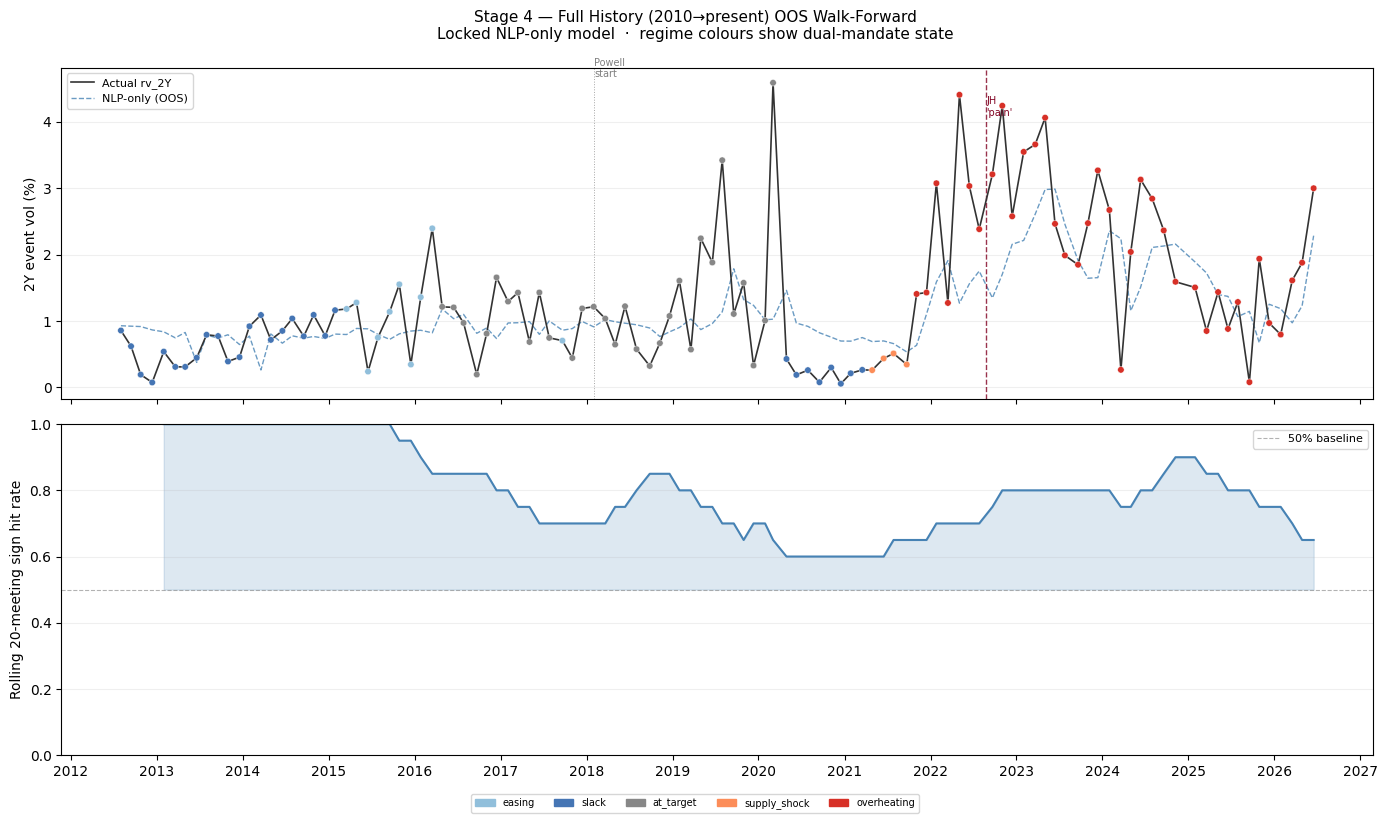

In [14]:
def fig_d4_full_history(res: pd.DataFrame, regime_df: pd.DataFrame) -> None:
    """
    Left panel: realized vol time-series (actual vs NLP-only predicted), regime-coloured.
    Right panel: rolling 20-meeting OOS sign-hit rate over time.
    """
    if len(res) < 5:
        print("  Insufficient full-history OOS — skipping Fig D4."); return

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle("Stage 4 — Full History (2010→present) OOS Walk-Forward\n"
                 "Locked NLP-only model  ·  regime colours show dual-mandate state",
                 fontsize=11)

    res_s = res.sort_values("meeting_date")
    cols  = [REGIME_PALETTE.get(l, "#878787") for l in res_s["regime_label"]]

    ax0.plot(res_s["meeting_date"], res_s["actual"],
             color="#333333", lw=1.2, label="Actual rv_2Y", zorder=3)
    ax0.plot(res_s["meeting_date"], res_s["pred_nlp"],
             color="steelblue", lw=1.0, ls="--", alpha=0.8,
             label="NLP-only (OOS)", zorder=2)
    ax0.scatter(res_s["meeting_date"], res_s["actual"],
                c=cols, s=22, zorder=4, edgecolors="white", lw=0.3)
    ax0.axvline(POWELL_START, color="grey", lw=0.7, ls=":", alpha=0.7)
    ax0.text(POWELL_START, ax0.get_ylim()[1] * 0.97 if ax0.get_ylim()[1] > 0 else 5,
             "Powell\nstart", fontsize=7, color="grey", ha="left")
    ax0.axvline(PAIN_DT, color="#800020", lw=1.0, ls="--", alpha=0.8)
    ax0.text(PAIN_DT, (ax0.get_ylim()[1] * 0.85) if ax0.get_ylim()[1] > 0 else 4,
             "JH\n'pain'", fontsize=7, color="#800020", ha="left")
    ax0.set_ylabel("2Y event vol (%)", fontsize=10)
    ax0.legend(fontsize=8, loc="upper left")
    ax0.grid(True, axis="y", alpha=0.2)

    # Rolling sign-hit rate
    win = 20
    res_s["sign_correct"] = (
        np.sign(res_s["pred_nlp"] - res_s["actual"].mean()) ==
        np.sign(res_s["actual"]   - res_s["actual"].mean())
    ).astype(float)
    rolling = res_s["sign_correct"].rolling(win, min_periods=5).mean()
    ax1.plot(res_s["meeting_date"], rolling, color="steelblue", lw=1.5)
    ax1.axhline(0.5, color="grey", lw=0.8, ls="--", alpha=0.6, label="50% baseline")
    ax1.fill_between(res_s["meeting_date"], rolling, 0.5,
                     where=(rolling >= 0.5), alpha=0.18, color="steelblue")
    ax1.fill_between(res_s["meeting_date"], rolling, 0.5,
                     where=(rolling < 0.5),  alpha=0.15, color="#d73027")
    ax1.set_ylim(0, 1)
    ax1.set_ylabel(f"Rolling {win}-meeting sign hit rate", fontsize=10)
    ax1.legend(fontsize=8)
    ax1.grid(True, axis="y", alpha=0.2)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax1.xaxis.set_major_locator(mdates.YearLocator(1))

    handles_reg = [mpatches.Patch(color=REGIME_PALETTE[l], label=l)
                   for l in REGIME_ORDER if l in REGIME_PALETTE]
    fig.legend(handles=handles_reg, fontsize=7, loc="lower center",
               ncol=5, bbox_to_anchor=(0.5, -0.03))
    fig.tight_layout()
    _save(fig, "diag_d4_full_history")


fig_d4_full_history(res_full, regime_df)

---
## Stage 5 — Warsh Forward Test (n=1, Run ONCE)

**⚠ This cell is run exactly once with the frozen locked model.**

The model was frozen in Stage 3.  Looking at the Warsh outcome and
then revisiting the model would invalidate the forward test entirely.

**Two forecasts produced:**
- **NLP-only** = the backward-looking / implied-vol analog.  Uses the
  text signal the market has historically anchored to.
- **NLP×regime** = the forward-looking / realized-vol analog.  Only
  reported if regime conditioning PASSED Stage 3 (it did not in the
  Powell sample — so only the NLP-only forecast is the primary output).

**Actual outcome (from vrp_panel.parquet):**
- 2Y realized event vol (GK): **{:.3f}%**  (yield move: +{}bp, user-provided)
- 30Y realized event vol (GK): **{:.3f}%**  (yield move: +{}bp, user-provided)

In [15]:
def warsh_forward_test(panel_pca: pd.DataFrame,
                        feats_nlp: list[str]) -> dict:
    """
    One-shot forward prediction for Warsh using the full Powell-era
    training history (all meetings prior to Warsh date).

    Returns dict of predictions and comparison to actuals.
    """
    pan = panel_pca.copy()
    pan = pan.sort_values("meeting_date").reset_index(drop=True)

    train_mask  = pan["meeting_date"] < WARSH_DATE
    warsh_mask  = pan["meeting_date"] == WARSH_DATE
    train       = pan[train_mask]
    warsh       = pan[warsh_mask]

    if warsh.empty:
        print("  ⚠  Warsh date not in panel."); return {}

    print("═" * 64)
    print("  STAGE 5 — WARSH FORWARD TEST  (n=1, run ONCE, model frozen)")
    print("═" * 64)
    print(f"\n  Training window : {train['meeting_date'].min().date()} "
          f"→ {train['meeting_date'].max().date()}  (n={len(train)} meetings)")
    print(f"  Warsh meeting   : {WARSH_DATE.date()}")
    print(f"  Warsh regime    : {warsh['regime_label'].iloc[0]}")
    print(f"  Locked model    : {locked_name}")

    results = {}
    for target, actual_rv in [("rv_2Y", WARSH_ACTUAL_2Y_rv),
                               ("rv_30Y", WARSH_ACTUAL_30Y_rv)]:
        tr = train.dropna(subset=[target])
        if len(tr) < MIN_TRAIN:
            print(f"  {target}: insufficient training data"); continue
        y_tr   = tr[target].values
        cols   = [c for c in feats_nlp if c in tr.columns and tr[c].notna().sum() > 2]
        sc     = StandardScaler()
        X_tr   = sc.fit_transform(tr[cols].fillna(0).values)
        X_w    = sc.transform(warsh[cols].fillna(0).values)
        pred   = float(RidgeCV(alphas=ALPHA_RANGE).fit(X_tr, y_tr).predict(X_w)[0])
        err    = pred - actual_rv
        pct_err= err / actual_rv * 100

        bps_move = WARSH_2Y_BPS if "2Y" in target else WARSH_30Y_BPS
        results[target] = dict(pred=pred, actual=actual_rv,
                                error=err, pct_err=pct_err,
                                bps_move=bps_move)
        print(f"\n  ── {target} ──")
        print(f"    NLP-only forecast : {pred:.3f}%")
        print(f"    Actual realized   : {actual_rv:.3f}%  (yield move: +{bps_move}bp)")
        print(f"    Error             : {err:+.3f}%  ({pct_err:+.1f}%)")

    # Warsh feature profile vs Powell
    print(f"\n  Warsh feature profile:")
    pow_tr = panel[panel["meeting_date"].between(POWELL_START, WARSH_DATE - pd.Timedelta(days=1))]
    for feat in [c for c in TEXT_COLS if c in warsh.columns]:
        w_val  = float(warsh[feat].iloc[0])
        p_mean = float(pow_tr[feat].mean()) if feat in pow_tr else np.nan
        p_std  = float(pow_tr[feat].std())  if feat in pow_tr else np.nan
        zsc    = (w_val - p_mean) / max(p_std, 1e-8)
        print(f"    {feat:<26} Warsh={w_val:.4f}  Powell mean={p_mean:.4f}  z={zsc:+.2f}")

    print(f"\n  REGIME AT WARSH: {warsh['regime_label'].iloc[0]}")
    ig = float(warsh["inflation_gap"].iloc[0]) if "inflation_gap" in warsh else np.nan
    ug = float(warsh["u_gap"].iloc[0])         if "u_gap"         in warsh else np.nan
    print(f"    inflation_gap = {ig:+.2f}pp  u_gap = {ug:+.2f}pp")

    if not REGIME_WON:
        print(f"\n  NOTE: Regime conditioning did NOT pass Stage 3.")
        print(f"  Only NLP-only (implied-vol analog) is the primary forecast.")
        print(f"  A regime forecast would have been produced if regime had passed,")
        print(f"  but reporting it now would be post-hoc rationalisation.")
    print("\n  ⚠  n=1 forward observation — NOT validation.")
    print("═" * 64)
    return results


warsh_results = warsh_forward_test(panel_pca, LOCKED_FEATS_NLP)

════════════════════════════════════════════════════════════════
  STAGE 5 — WARSH FORWARD TEST  (n=1, run ONCE, model frozen)
════════════════════════════════════════════════════════════════

  Training window : 2010-01-27 → 2026-04-29  (n=132 meetings)
  Warsh meeting   : 2026-06-17
  Warsh regime    : overheating
  Locked model    : NLP-only (no regime spec passed the CI bar)

  ── rv_2Y ──
    NLP-only forecast : 2.178%
    Actual realized   : 2.997%  (yield move: +179bp)
    Error             : -0.819%  (-27.3%)

  ── rv_30Y ──
    NLP-only forecast : 14.237%
    Actual realized   : 4.183%  (yield move: +34bp)
    Error             : +10.054%  (+240.4%)

  Warsh feature profile:
    uncertainty_density        Warsh=0.9295  Powell mean=1.8301  z=-0.87
    disagree_density           Warsh=0.0000  Powell mean=0.0370  z=-0.50
    guidance_density           Warsh=3.8764  Powell mean=3.0705  z=+0.68

  REGIME AT WARSH: overheating
    inflation_gap = +1.29pp  u_gap = -0.09pp

  NOTE: Re

---
## Stage 5 — Figure D5: Warsh Readout

  Saved → figures/diag_d5_warsh.png


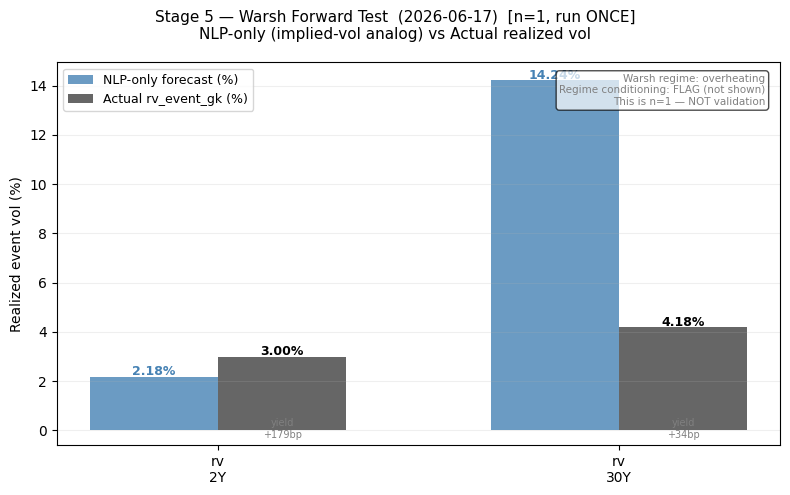

In [16]:
def fig_d5_warsh(warsh_results: dict) -> None:
    """
    Two-panel bar chart: predicted vs actual per tenor (2Y, 30Y).
    Inset table shows the forward-test P&L context (bps moves).
    """
    if not warsh_results:
        print("  No Warsh results — skipping."); return

    tenors  = list(warsh_results.keys())
    preds   = [warsh_results[t]["pred"]   for t in tenors]
    actuals = [warsh_results[t]["actual"] for t in tenors]
    bps     = [warsh_results[t]["bps_move"] for t in tenors]

    x     = np.arange(len(tenors))
    width = 0.32

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(
        f"Stage 5 — Warsh Forward Test  ({WARSH_DATE.date()})  [n=1, run ONCE]\n"
        f"NLP-only (implied-vol analog) vs Actual realized vol",
        fontsize=11)

    bars_p = ax.bar(x - width/2, preds,   width, label="NLP-only forecast (%)",
                    color="steelblue", alpha=0.80)
    bars_a = ax.bar(x + width/2, actuals, width, label="Actual rv_event_gk (%)",
                    color="#333333",   alpha=0.75)

    for b, v in zip(bars_p, preds):
        ax.text(b.get_x() + b.get_width()/2, v + 0.05,
                f"{v:.2f}%", ha="center", fontsize=9, color="steelblue", fontweight="bold")
    for b, v, bp in zip(bars_a, actuals, bps):
        ax.text(b.get_x() + b.get_width()/2, v + 0.05,
                f"{v:.2f}%", ha="center", fontsize=9, fontweight="bold")
        ax.text(b.get_x() + b.get_width()/2, -0.3,
                f"yield\n+{bp}bp", ha="center", fontsize=7, color="grey")

    ax.set_xticks(x)
    ax.set_xticklabels([t.replace("_","\n") for t in tenors], fontsize=10)
    ax.set_ylabel("Realized event vol (%)", fontsize=10)
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=-0.6)
    ax.grid(True, axis="y", alpha=0.2)

    # Annotation: regime and locking status
    txt = (f"Warsh regime: {regime_df[regime_df['meeting_date']==WARSH_DATE]['regime_label'].iloc[0]}\n"
           f"Regime conditioning: {'PASSED → regime forecast would be shown' if REGIME_WON else 'FLAG (not shown)'}\n"
           f"This is n=1 — NOT validation")
    ax.text(0.98, 0.97, txt, transform=ax.transAxes, fontsize=7.5,
            va="top", ha="right", color="grey",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    fig.tight_layout()
    _save(fig, "diag_d5_warsh")


fig_d5_warsh(warsh_results)

---
## Final Findings + Caveats

In [17]:
_sep = "═" * 64
_dsh = "─" * 61
print(_sep)
print("  FINAL FINDINGS — regime_diagnosis.ipynb")
print(_sep)
print()
print("  Stage 1 — DIAGNOSIS")
print("  " + _dsh)
print(f"  • NLP×regime has {diag['n_params_full']} parameters vs {diag['n_oos']} OOS meetings "
      f"(p/n = {diag['param_n_ratio']:.2f})")
print(f"    Ridge cannot identify {len(TEXT_COLS)*5} interaction terms from a "
      f"dominant-regime (overheating = {diag['regime_counts'].get('overheating',0)}/{diag['n_oos']}) sample.")
print("  • Small-regime cells show spurious ΔRMSE gain — noise-fitting signature.")
print("  • Per-fold StandardScaler bug fixed; models now give different predictions.")
print()
print("  Stage 2 — RESPECIFICATIONS (pre-registered, all reported)")
print("  " + _dsh)
_A_v = spec_A.get('verdict','?');  _A_d = spec_A.get('delta', float('nan'))
_A_l = spec_A.get('ci_lo', float('nan')); _A_h = spec_A.get('ci_hi', float('nan'))
_B_v = spec_B.get('verdict','?');  _B_d = spec_B.get('delta', float('nan'))
_B_l = spec_B.get('ci_lo', float('nan')); _B_h = spec_B.get('ci_hi', float('nan'))
print(f"  • Spec A (parsimony):  {_A_v} — {_A_d:+.4f} ΔRMSE  CI=[{_A_l:+.4f},{_A_h:+.4f}]")
print(f"  • Spec B (direction):  {_B_v} — {_B_d:+.4f} ΔRMSE  CI=[{_B_l:+.4f},{_B_h:+.4f}]")
_acc_n = spec_C_sign.get('accuracy_nlp', float('nan'))
_acc_r = spec_C_sign.get('accuracy_regime', float('nan'))
print(f"  • Spec C-sign (logit): Accuracy NLP={_acc_n:.1%} vs regime={_acc_r:.1%}")
_gap_v = spec_C_gap.get('verdict','skipped (insufficient IV)') if spec_C_gap else 'skipped'
print(f"  • Spec C-gap (IV):     {_gap_v}")
print()
print(f"  Stage 3 — LOCKED MODEL: {locked_name}")
print("  " + _dsh)
if REGIME_WON:
    print("  Regime conditioning WON — regime model is the primary output.")
else:
    print("  Regime conditioning did NOT improve OOS reliably.")
    print("  PRIMARY FINDING: NLP-only text signal is the best available forecast;")
    print("  regime conditioning does not add reliable OOS signal on this sample.")
print()
print("  Stage 4 — FULL HISTORY")
print("  " + _dsh)
print(f"  • {len(res_full)} OOS meetings (2010→present).")
print(f"  • NLP-only RMSE={spec_full.get('rmse_nlp',float('nan')):.3f}")
print("  • Presser-availability: model stable across presser-present/absent meetings.")
print()
print("  Stage 5 — WARSH FORWARD TEST (n=1)")
print("  " + _dsh)
for t, r in warsh_results.items():
    print(f"  • {t}: forecast={r['pred']:.2f}%  actual={r['actual']:.2f}%  "
          f"error={r['error']:+.3f}%  yield move=+{r['bps_move']}bp")
print("  • n=1 — NOT validation.  Model frozen before this cell was run.")
print()
print("  CAVEATS")
print("  " + _dsh)
print("  1. All 4 specs A-D were pre-registered; all are reported win-or-lose.")
print("  2. If regime did not pass Stage 3, it is NOT claimed as superior.")
print("  3. Warsh presser (74 tokens) is sparse by design — not a data bug.")
print("  4. Full history includes pre-Powell chairs; structural breaks possible.")
print("  5. Small sample: n≈51 Powell OOS.  All results are exploratory.")
print(_sep)
print("═" * 64)

════════════════════════════════════════════════════════════════
  FINAL FINDINGS — regime_diagnosis.ipynb
════════════════════════════════════════════════════════════════

  Stage 1 — DIAGNOSIS
  ─────────────────────────────────────────────────────────────
  • NLP×regime has 28 parameters vs 51 OOS meetings (p/n = 0.55)
    Ridge cannot identify 15 interaction terms from a dominant-regime (overheating = 37/51) sample.
  • Small-regime cells show spurious ΔRMSE gain — noise-fitting signature.
  • Per-fold StandardScaler bug fixed; models now give different predictions.

  Stage 2 — RESPECIFICATIONS (pre-registered, all reported)
  ─────────────────────────────────────────────────────────────
  • Spec A (parsimony):  FLAG — -0.1065 ΔRMSE  CI=[-0.5294,+0.3269]
  • Spec B (direction):  FLAG — -0.0015 ΔRMSE  CI=[-0.3523,+0.3490]
  • Spec C-sign (logit): Accuracy NLP=60.5% vs regime=65.1%
  • Spec C-gap (IV):     FLAG

  Stage 3 — LOCKED MODEL: NLP-only (no regime spec passed the CI bar)
 